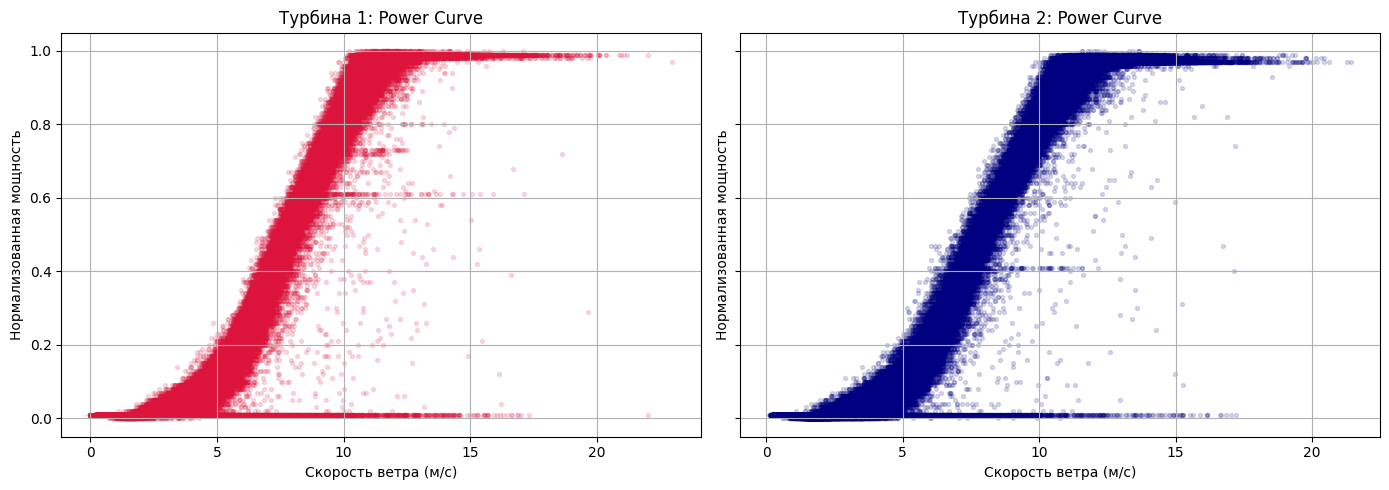

Первые 10 строк Power Curve с мощностью выше нуля:
   wind_bin  power
0       0.0   0.01
1       1.0   0.01
2       2.0   0.01
3       3.0   0.02
4       4.0   0.06
5       5.0   0.12
6       6.0   0.21
7       7.0   0.35
8       8.0   0.51
9       9.0   0.66


In [5]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

def load_turbine(filename):
    path = Path("/content") / filename
    df = pd.read_csv(path)

    # Ищем столбцы без привязки к записи единиц измерения: m/s или м/с
    wind_col = next(
        col for col in df.columns
        if "средняя скорость ветра" in col.lower()
    )
    power_col = next(
        col for col in df.columns
        if "нормализованная активная мощность" in col.lower()
    )

    result = pd.DataFrame({
        "wind_speed": pd.to_numeric(df[wind_col], errors="coerce"),
        "power": pd.to_numeric(df[power_col], errors="coerce"),
    })
    return result.dropna()

turbine1 = load_turbine("turbine1.csv")
turbine2 = load_turbine("turbine2.csv")

# График для каждой турбины
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, data, title, color in [
    (axes[0], turbine1, "Турбина 1", "crimson"),
    (axes[1], turbine2, "Турбина 2", "navy"),
]:
    ax.scatter(data["wind_speed"], data["power"],
               s=8, alpha=0.15, color=color)
    ax.set_title(f"{title}: Power Curve")
    ax.set_xlabel("Скорость ветра (м/с)")
    ax.set_ylabel("Нормализованная мощность")
    ax.grid(True)

plt.tight_layout()
plt.savefig("/content/power_curves_turbines.png", dpi=300)
plt.show()

# Общая Power Curve: медианная мощность для каждой
# округлённой до целого скорости ветра
all_data = pd.concat([turbine1, turbine2], ignore_index=True)
all_data["wind_bin"] = all_data["wind_speed"].round()

power_curve_lookup = (
    all_data.groupby("wind_bin", as_index=False)["power"]
    .median()
    .sort_values("wind_bin")
)

print("Первые 10 строк Power Curve с мощностью выше нуля:")
print(power_curve_lookup[power_curve_lookup["power"] > 0].head(10))